In [1]:
import kagglehub
path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")


Using Colab cache for faster access to the 'telco-customer-churn-11-1-3' dataset.


In [2]:
import os
print(os.listdir(path))

['telco.csv']


In [3]:
import pandas as pd
df = pd.read_csv(path + "/telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
df.shape

(7043, 50)

In [5]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [6]:
df["Churn Label"].value_counts(normalize=True)

,proportion
Churn Label,
No,0.73463
Yes,0.26537


In [7]:
df["Churn Label"].value_counts(normalize=True)*100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [8]:
df["Customer Status"].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


In [9]:
df["CLTV"].describe()

,CLTV
count,7043.000000
mean,4400.295755
std,1183.057152
min,2003.000000
25%,3469.000000
50%,4527.000000
75%,5380.500000
max,6500.000000


In [10]:
df['CLTV'].corr(df['Churn Label'].map({"Yes":1,"No":0}))

np.float64(-0.12746310171744957)

In [11]:
df.groupby("Churn Label")["CLTV"].mean()

,CLTV
Churn Label,
No,4490.921337
Yes,4149.414660


In [12]:
df.groupby("Churn Label")["Tenure in Months"].mean()

,Tenure in Months
Churn Label,
No,37.591225
Yes,17.979133


In [13]:
df.groupby("Churn Label")["Monthly Charge"].mean()

,Monthly Charge
Churn Label,
No,61.265124
Yes,74.441332


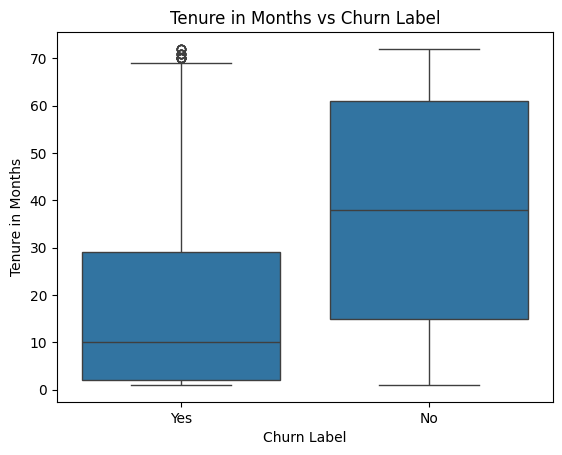

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df,x="Churn Label",y="Tenure in Months")
plt.title("Tenure in Months vs Churn Label")
plt.show()

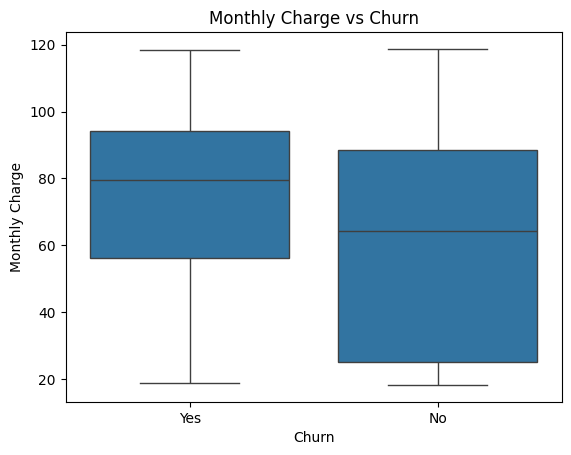

In [15]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charge"
)

plt.title("Monthly Charge vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charge")
plt.show()

In [16]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


In [17]:
pd.crosstab(
    df["Satisfaction Score"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Satisfaction Score,,
1,0.000000,100.000000
2,0.000000,100.000000
3,83.902439,16.097561
4,100.000000,0.000000
5,100.000000,0.000000


In [18]:
df["Satisfaction Score"].value_counts().sort_index()

,count
Satisfaction Score,
1,922
2,518
3,2665
4,1789
5,1149


In [19]:
pd.crosstab(df["Total Charges"],
            df["Churn Label"])

Churn Label,No,Yes
Total Charges,,
18.80,1,0
18.85,1,1
18.90,1,0
19.00,1,0
19.05,1,0
...,...,...
8564.75,1,0
8594.40,1,0
8670.10,1,0


In [20]:
y = df["Payment Method"]
print(y)

0       Bank Withdrawal
1           Credit Card
2       Bank Withdrawal
3       Bank Withdrawal
4       Bank Withdrawal
             ...       
7038    Bank Withdrawal
7039       Mailed Check
7040        Credit Card
7041    Bank Withdrawal
7042    Bank Withdrawal
Name: Payment Method, Length: 7043, dtype: object


In [21]:
pd.crosstab(df["Payment Method"],df["Churn Label"],normalize="index")*100

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992
Mailed Check,63.116883,36.883117


In [22]:
y=df["Internet Service"]
print(y)

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039    Yes
7040    Yes
7041    Yes
7042    Yes
Name: Internet Service, Length: 7043, dtype: object


In [23]:
df.groupby("Internet Service")["Churn Label"].value_counts(normalize=True)*100

Internet Service  Churn Label
No                No             92.595020
                  Yes             7.404980
Yes               No             68.171107
                  Yes            31.828893
Name: proportion, dtype: float64

In [24]:
df["Internet Service"].value_counts()

,count
Internet Service,
Yes,5517
No,1526


In [25]:
df["Internet Service"].value_counts(normalize=True) * 100

,proportion
Internet Service,
Yes,78.333097
No,21.666903


In [26]:
df.groupby("Internet Service")["Churn Label"].value_counts(normalize=True)*100

Internet Service  Churn Label
No                No             92.595020
                  Yes             7.404980
Yes               No             68.171107
                  Yes            31.828893
Name: proportion, dtype: float64

In [27]:
y=df["Age"]
print(y)

0       78
1       74
2       71
3       78
4       80
        ..
7038    30
7039    38
7040    30
7041    32
7042    44
Name: Age, Length: 7043, dtype: int64


In [28]:
df.groupby("Age")["Churn Label"].value_counts(normalize=True)*100

Age  Churn Label
19   No             85.826772
     Yes            14.173228
20   No             76.377953
     Yes            23.622047
21   No             74.285714
                      ...    
78   Yes            47.619048
79   No             64.473684
     Yes            35.526316
80   No             56.060606
     Yes            43.939394
Name: proportion, Length: 124, dtype: float64

In [29]:
import pandas as pd
from scipy.stats import chi2_contingency

# Your target column
y = df["Churn Label"].map({"Yes": 1, "No": 0})

# List all candidate feature columns (edit this list to match your exact column names)
categorical_cols = [
    "Gender", "Contract", "Payment Method", "Internet Service",
    "Dependents", "Phone Service", "Multiple Lines", "Online Security",
    "Online Backup", "Device Protection Plan", "Premium Tech Support",
    "Streaming TV", "Streaming Movies", "Streaming Music", "Unlimited Data"
]

numeric_cols = [
    "Tenure in Months", "Monthly Charge", "Total Charges", "Number of Referrals"
]

# ---------- 1. Categorical columns: Chi-square test ----------
print("=== CATEGORICAL FEATURES ===\n")
results_cat = []

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["Churn Label"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    results_cat.append({"Column": col, "p-value": p_value})

results_cat_df = pd.DataFrame(results_cat).sort_values("p-value")
print(results_cat_df.to_string(index=False))

# ---------- 2. Numeric columns: Correlation ----------
print("\n=== NUMERIC FEATURES ===\n")
results_num = []

for col in numeric_cols:
    corr = df[col].corr(y)
    results_num.append({"Column": col, "Correlation with Churn": corr})

results_num_df = pd.DataFrame(results_num).sort_values(
    "Correlation with Churn", key=abs, ascending=False
)
print(results_num_df.to_string(index=False))

=== CATEGORICAL FEATURES ===

                Column      p-value
              Contract 0.000000e+00
            Dependents 2.500972e-96
      Internet Service 2.920300e-81
        Payment Method 4.374168e-74
       Online Security 1.232098e-46
        Unlimited Data 3.231434e-44
  Premium Tech Support 2.923567e-43
         Online Backup 6.214093e-12
Device Protection Plan 3.315693e-08
          Streaming TV 1.302484e-07
      Streaming Movies 2.997474e-07
       Streaming Music 1.461276e-04
        Multiple Lines 8.433795e-04
         Phone Service 3.387825e-01
                Gender 4.865787e-01

=== NUMERIC FEATURES ===

             Column  Correlation with Churn
   Tenure in Months               -0.352861
Number of Referrals               -0.286540
      Total Charges               -0.198546
     Monthly Charge                0.193356


In [30]:
X = df[["Contract", "Dependents", "Internet Service", "Payment Method",
    "Online Security", "Unlimited Data", "Premium Tech Support",
    "Online Backup", "Device Protection Plan", "Streaming TV",
    "Streaming Movies", "Streaming Music", "Multiple Lines",
    "Tenure in Months", "Number of Referrals", "Total Charges", "Monthly Charge"]]

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})
print(X.shape)
print(y.value_counts())

(7043, 17)
Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(4930, 17) (4930,)
(1056, 17) (1056,)
(1057, 17) (1057,)


In [32]:
print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


Training:
Churn Label
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Validation:
Churn Label
0    0.734848
1    0.265152
Name: proportion, dtype: float64

Test:
Churn Label
0    0.734153
1    0.265847
Name: proportion, dtype: float64


In [33]:
categorical_features =X_train.select_dtypes(include=["object"]).columns
numerical_features=X_train.select_dtypes(exclude=["object"]).columns
print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')

Numerical:
Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object')


In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [35]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                ('num', StandardScaler(),
                                 Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])

In [36]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score
baseline_accuracy = accuracy_score(y_test,baseline_predictions)
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")

Baseline Accuracy: 0.73


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [39]:
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [40]:
y_val_pred = logistic_model.predict(X_val)

In [41]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.8267045454545454


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[693  83]
 [100 180]]


In [43]:
print("True Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives  :", cm[1, 1])

True Negatives : 693
False Positives: 83
False Negatives: 100
True Positives  : 180


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       776
           1       0.68      0.64      0.66       280

    accuracy                           0.83      1056
   macro avg       0.78      0.77      0.77      1056
weighted avg       0.82      0.83      0.82      1056



In [45]:
import kagglehub
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")
df = pd.read_csv(path + "/telco.csv")

# Define X and y (from cell 9Tr-TiPrPkcy)
X = df[["Contract", "Dependents", "Internet Service", "Payment Method",
    "Online Security", "Unlimited Data", "Premium Tech Support",
    "Online Backup", "Device Protection Plan", "Streaming TV",
    "Streaming Movies", "Streaming Music", "Multiple Lines",
    "Tenure in Months", "Number of Referrals", "Total Charges", "Monthly Charge"]]

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

# Perform train-test-split (from cell P2yJj5ZyT66O)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Redefining categorical and numerical features for robustness
categorical_features = X_train.select_dtypes(include=["object"]).columns
numerical_features = X_train.select_dtypes(exclude=["object"]).columns

# Redefining the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Fit the preprocessor (using X_train to avoid data leakage)
preprocessor.fit(X_train)

logistic_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

Using Colab cache for faster access to the 'telco-customer-churn-11-1-3' dataset.


In [46]:
logistic_balanced.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [47]:
y_val_pred_balanced = logistic_balanced.predict(X_val)

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_balanced))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       776
           1       0.56      0.86      0.68       280

    accuracy                           0.79      1056
   macro avg       0.75      0.81      0.76      1056
weighted avg       0.84      0.79      0.80      1056



In [49]:
y_val_proba = logistic_model.predict_proba(X_val)


In [50]:
print(y_val_proba[:10])

[[0.7501793  0.2498207 ]
 [0.94150448 0.05849552]
 [0.98289237 0.01710763]
 [0.99531528 0.00468472]
 [0.56966284 0.43033716]
 [0.47197961 0.52802039]
 [0.18305458 0.81694542]
 [0.99826887 0.00173113]
 [0.58125663 0.41874337]
 [0.97785291 0.02214709]]


In [51]:
churn_probability = logistic_model.predict_proba(X_val)[:, 1]

In [52]:
print(churn_probability[:10])

[0.2498207  0.05849552 0.01710763 0.00468472 0.43033716 0.52802039
 0.81694542 0.00173113 0.41874337 0.02214709]


In [53]:
y_val_proba = logistic_model.predict_proba(X_val)

print(y_val_proba[:10])

churn_probability = logistic_model.predict_proba(X_val)[:, 1]

print(churn_probability[:10])

[[0.7501793  0.2498207 ]
 [0.94150448 0.05849552]
 [0.98289237 0.01710763]
 [0.99531528 0.00468472]
 [0.56966284 0.43033716]
 [0.47197961 0.52802039]
 [0.18305458 0.81694542]
 [0.99826887 0.00173113]
 [0.58125663 0.41874337]
 [0.97785291 0.02214709]]
[0.2498207  0.05849552 0.01710763 0.00468472 0.43033716 0.52802039
 0.81694542 0.00173113 0.41874337 0.02214709]


In [54]:
y_val_pred_04 = (churn_probability >= 0.4).astype(int)

In [55]:
print(classification_report(y_val, y_val_pred_04))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       776
           1       0.63      0.75      0.69       280

    accuracy                           0.82      1056
   macro avg       0.77      0.80      0.78      1056
weighted avg       0.83      0.82      0.82      1056



In [56]:

from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [57]:
tree_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [58]:
y_val_pred_tree = tree_model.predict(X_val)

In [59]:
print(classification_report(y_val, y_val_pred_tree))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       776
           1       0.66      0.54      0.59       280

    accuracy                           0.80      1056
   macro avg       0.75      0.72      0.73      1056
weighted avg       0.79      0.80      0.80      1056



In [60]:
from sklearn.metrics import f1_score

depths = [2, 3, 5, 7, 10]

for depth in depths:
    tree = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    val_pred = tree.predict(X_val)

    train_f1 = f1_score(y_train, train_pred, pos_label=1)
    val_f1 = f1_score(y_val, val_pred, pos_label=1)

    print(
        f"Depth: {depth} | "
        f"Training F1: {train_f1:.3f} | "
        f"Validation F1: {val_f1:.3f}"
    )

Depth: 2 | Training F1: 0.600 | Validation F1: 0.576
Depth: 3 | Training F1: 0.618 | Validation F1: 0.597
Depth: 5 | Training F1: 0.651 | Validation F1: 0.594
Depth: 7 | Training F1: 0.723 | Validation F1: 0.656
Depth: 10 | Training F1: 0.821 | Validation F1: 0.640


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42
    ))
])

In [62]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=7, n_estimators=200,
                                        random_state=42))])

In [63]:
y_val_pred_rf = rf_model.predict(X_val)

In [64]:
print(classification_report(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       776
           1       0.74      0.62      0.67       280

    accuracy                           0.84      1056
   macro avg       0.80      0.77      0.78      1056
weighted avg       0.84      0.84      0.84      1056



In [65]:
rf_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        class_weight="balanced",
        random_state=42
    ))
])

In [66]:
rf_balanced.fit(X_train, y_train)

y_val_pred_rf_balanced = rf_balanced.predict(X_val)

print(classification_report(y_val, y_val_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       776
           1       0.60      0.85      0.70       280

    accuracy                           0.81      1056
   macro avg       0.77      0.82      0.78      1056
weighted avg       0.85      0.81      0.82      1056



In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

In [68]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 7, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

In [69]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [70]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multi...
      dtype='object')),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [5, 7, 10],
                         'model__min_samples_leaf': [1, 2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [71]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best CV F1:
0.6851655565111325


In [72]:
best_rf = grid_search.best_estimator_

y_val_pred_tuned = best_rf.predict(X_val)

print(classification_report(y_val, y_val_pred_tuned))

              precision    recall  f1-score   support

           0       0.91      0.82      0.87       776
           1       0.62      0.79      0.69       280

    accuracy                           0.81      1056
   macro avg       0.77      0.81      0.78      1056
weighted avg       0.84      0.81      0.82      1056



In [73]:
final_model = rf_balanced

y_test_pred = final_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.85       776
           1       0.59      0.88      0.70       281

    accuracy                           0.81      1057
   macro avg       0.77      0.83      0.78      1057
weighted avg       0.85      0.81      0.81      1057



In [74]:
from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(y_test, y_test_pred)

print(cm_test)

[[605 171]
 [ 35 246]]


In [75]:
print(pd.crosstab(
    df["Customer Status"],
    df["Churn Label"],
    margins=True
))

Churn Label        No   Yes   All
Customer Status                  
Churned             0  1869  1869
Joined            454     0   454
Stayed           4720     0  4720
All              5174  1869  7043


In [76]:
print(df["Customer Status"].value_counts())

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [77]:
df_existing = df[df["Customer Status"] != "Joined"].copy()

print(df_existing.shape)
print(df_existing["Customer Status"].value_counts())

(6589, 50)
Customer Status
Stayed     4720
Churned    1869
Name: count, dtype: int64


In [78]:
# Remove newly joined customers
df_existing = df[df["Customer Status"] != "Joined"].copy()


# Features
final_features = [
    "Contract",
    "Dependents",
    "Internet Service",
    "Payment Method",
    "Online Security",
    "Unlimited Data",
    "Premium Tech Support",
    "Online Backup",
    "Device Protection Plan",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Multiple Lines",
    "Tenure in Months",
    "Number of Referrals",
    "Total Charges",
    "Monthly Charge"
]

X = df_existing[final_features]

# Target
y = df_existing["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Identify feature types
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

# Final model
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        class_weight="balanced",
        random_state=42
    ))
])

In [79]:
print("Dataset:", df_existing.shape)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget:")
print(y.value_counts())

Dataset: (6589, 50)
Training: (4612, 17)
Validation: (988, 17)
Test: (989, 17)

Target:
Churn Label
0    4720
1    1869
Name: count, dtype: int64


In [80]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Contract', 'Dependents', 'Internet Service', 'Payment Method',
       'Online Security', 'Unlimited Data', 'Premium Tech Support',
       'Online Backup', 'Device Protection Plan', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Multiple Lines'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Tenure in Months', 'Number of Referrals', 'Total Charges',
       'Monthly Charge'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=7,
                                        n_estimators=200, random_state=42))])

In [81]:
y_val_pred = final_model.predict(X_val)

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.94      0.82      0.87       708
           1       0.65      0.86      0.74       280

    accuracy                           0.83       988
   macro avg       0.79      0.84      0.81       988
weighted avg       0.85      0.83      0.83       988



In [83]:
y_test_pred = final_model.predict(X_test)

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.93      0.83      0.87       708
           1       0.66      0.83      0.73       281

    accuracy                           0.83       989
   macro avg       0.79      0.83      0.80       989
weighted avg       0.85      0.83      0.83       989



In [84]:
rf = final_model.named_steps["model"]

In [85]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

In [86]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                            Feature  Importance
0      cat__Contract_Month-to-Month    0.221629
28            num__Tenure in Months    0.155869
2            cat__Contract_Two Year    0.116659
29         num__Number of Referrals    0.093751
30               num__Total Charges    0.077663
31              num__Monthly Charge    0.057587
3                cat__Dependents_No    0.044937
1            cat__Contract_One Year    0.039359
4               cat__Dependents_Yes    0.037571
5          cat__Internet Service_No    0.023370
6         cat__Internet Service_Yes    0.022369
8   cat__Payment Method_Credit Card    0.014232
15    cat__Premium Tech Support_Yes    0.013536
14     cat__Premium Tech Support_No    0.009922
10          cat__Online Security_No    0.009207


In [87]:
!pip install shap -q


In [88]:
import shap

In [89]:
preprocessor = final_model.named_steps["preprocessor"]
rf = final_model.named_steps["model"]

In [90]:
X_test_transformed = preprocessor.transform(X_test)

In [91]:
feature_names = preprocessor.get_feature_names_out()

In [92]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_transformed)

In [93]:
print(type(shap_values))

<class 'numpy.ndarray'>


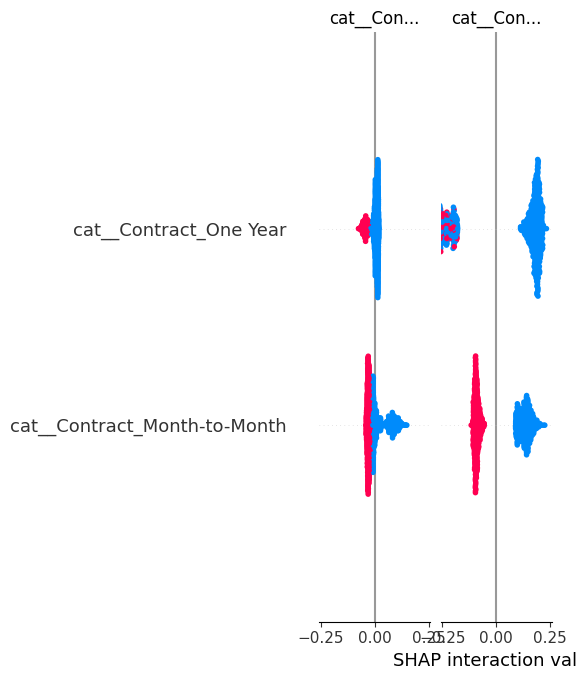

In [94]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [95]:
print(shap_values.shape)

(989, 32, 2)


In [96]:
shap_values_churn = shap_values[:, :, 1]

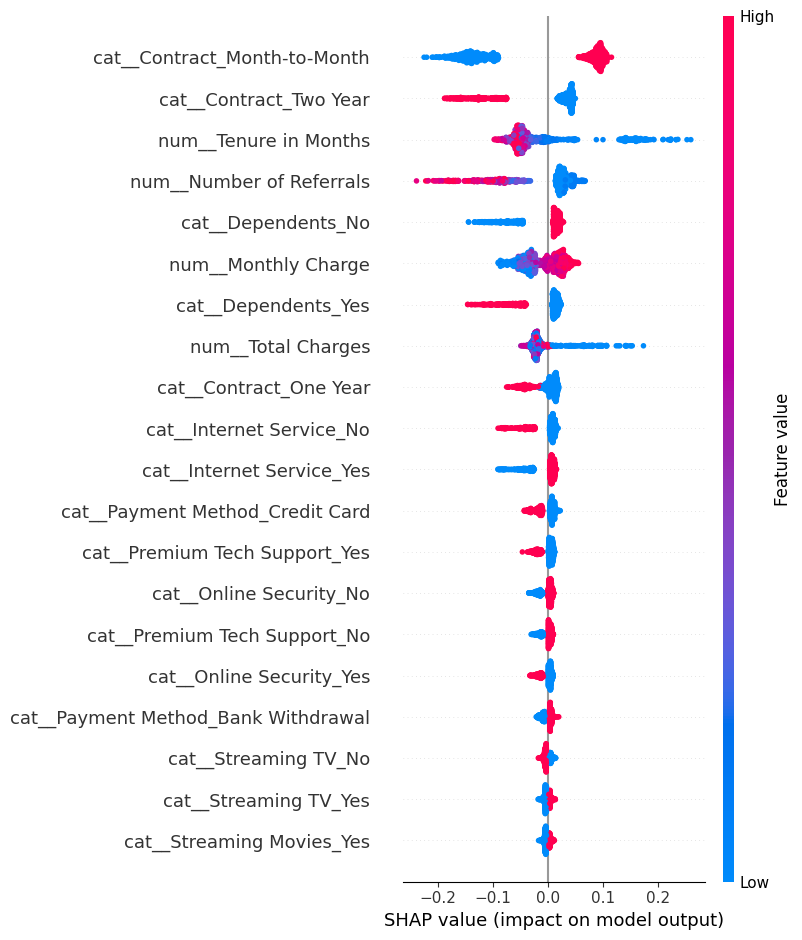

In [97]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names
)

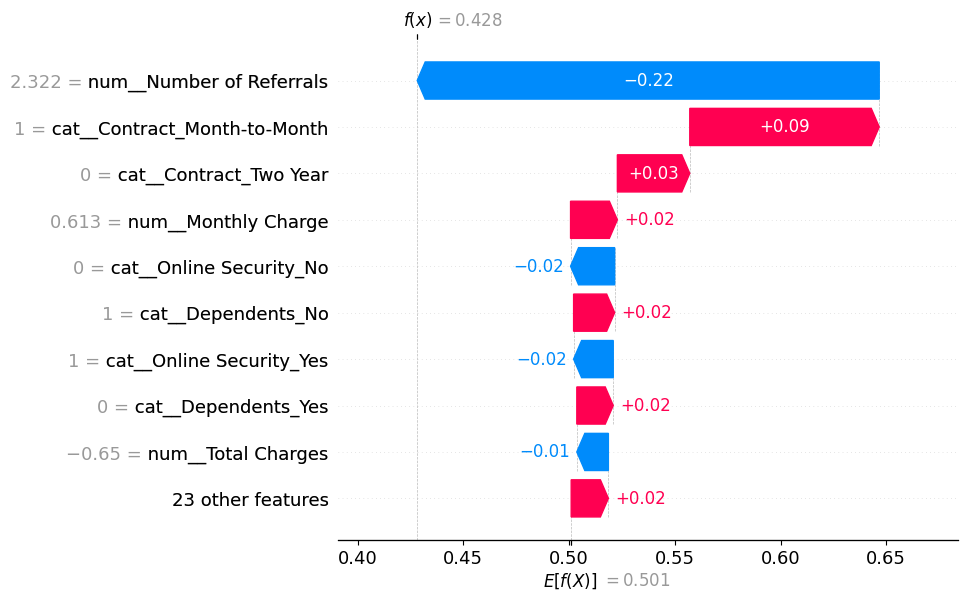

In [98]:
customer_idx = 0

customer_shap = shap_values_churn[customer_idx]
customer_data = X_test_transformed[customer_idx]

shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value[1],
        data=customer_data,
        feature_names=feature_names
    )
)

In [99]:
import numpy as np

def explain_customer(model, X_data, index=0, top_n=3):

    # Customer data
    customer = X_data.iloc[[index]]

    # Churn probability
    probability = model.predict_proba(customer)[0, 1]

    # Risk level
    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    # Transform customer
    transformed_customer = preprocessor.transform(customer)

    # SHAP values
    customer_shap = explainer.shap_values(transformed_customer)

    # Handle SHAP output
    if customer_shap.ndim == 3:
        customer_shap = customer_shap[:, :, 1]

    customer_shap = customer_shap[0]

    # Get top factors pushing toward churn
    positive_indices = np.argsort(customer_shap)[::-1]

    reasons = []

    for i in positive_indices:
        if customer_shap[i] <= 0:
            break

        feature = feature_names[i]

        # Make feature name business-friendly
        feature = feature.replace("cat__", "")
        feature = feature.replace("num__", "")
        feature = feature.replace("_", " ")

        value = transformed_customer[0, i]

        reasons.append(feature)

        if len(reasons) == top_n:
            break

    print("CUSTOMER CHURN ANALYSIS")
    print("-----------------------")
    print(f"Churn Probability: {probability:.1%}")
    print(f"Risk Level: {risk}")

    print("\nMain reasons:")
    for n, reason in enumerate(reasons, 1):
        print(f"{n}. {reason}")

    print("\nRecommended action:")

    if risk == "HIGH":
        print("Contact the customer and offer a suitable retention incentive.")
    elif risk == "MEDIUM":
        print("Monitor the customer and consider a retention offer.")
    else:
        print("No immediate retention action required.")

In [100]:
explain_customer(final_model, X_test, index=0)

CUSTOMER CHURN ANALYSIS
-----------------------
Churn Probability: 42.8%
Risk Level: MEDIUM

Main reasons:
1. Contract Month-to-Month
2. Contract Two Year
3. Monthly Charge

Recommended action:
Monitor the customer and consider a retention offer.


In [101]:
import joblib

joblib.dump(final_model, "churn_model.pkl")

['churn_model.pkl']

In [102]:
import os

print(os.path.getsize("churn_model.pkl"))

2433026
